# Table of Content <a id='toc'></a>


&nbsp;&nbsp;&nbsp;&nbsp;[1. Correlation](#0)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.1. Pearson's (linear) correlation](#1)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.2. Spearman's (rank) correlation coefficient](#2)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.3. Significance of Pearson and Spearman correlation coefficient.](#3)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.4. Kendall tau correlation coefficient (for fun)](#4)

&nbsp;&nbsp;&nbsp;&nbsp;[Exercise 01](#5)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.5 Correlation and causation](#6)

&nbsp;&nbsp;&nbsp;&nbsp;[2. Linear regression](#7)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.1. Presentation](#8)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2. Underlying hypothesis](#9)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3. Goodness of fit](#10)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.4. Confidence interval and test statistics](#11)

&nbsp;&nbsp;&nbsp;&nbsp;[Exercise 02](#E02)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[Extension 1](#E1)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[E1.1 Unidimensional, multiple covariables](#E1.1)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[E1.2 Multidimensional : more than 1 co-variable](#E1.2)


In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image
import seaborn as sns
import scipy.stats as stats 
import pandas as pd
import numpy as np

from matplotlib import collections  as mc
from operator import itemgetter
from mpl_toolkits.mplot3d import Axes3D

### This is some configuration to make the plots work better when presenting online
%matplotlib inline

import matplotlib.pylab as pylab
pylab.rcParams['figure.figsize'] = 10, 10
plt.rc("font", size=16)



So far we have seen how to evaluate the relationship between
* 2 categorical variables (fisher's exact test, chi-square)
* 1 quantitative and a categorical variable (t-test, anova)

Now we are going to see how to relate 2 quantitative variables together.

In this notebook we will use the following dataset:

In [7]:
df=pd.read_csv('data/etubiol.csv')
df.rename(columns={i:i.replace('.','_') for i in df.columns},inplace=True)
df.eye_colour = df.eye_colour.astype(str) # making eye colour a non-numerical variable
df.diet = df.diet.astype(str) # making diet a non-numerical variable
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2
df['bmi'] = df['bmi'].round(1)  # optional: round to 1 decimal
df.head()

,gender,height,weight,shoe_size,right_left_handed,smoker_nonsmoker,hair_colour,eye_colour,R_wrist_girth,L_wrist_girth,nb_siblings,birth_place,height_M,height_F,nb_siblings_F,nb_siblings_M,diet,bmi
0,M,183,72,42.0,R,NS,lb,1,17.0,16.6,2,vd,170,174,5,1,4,21.5
1,M,183,68,43.0,R,NS,db,2,17.0,16.0,1,fr,170,178,4,2,2,20.3
2,M,182,73,44.0,R,NS,bl,1,18.5,18.0,2,ne,168,181,3,5,4,22.0
3,M,175,66,41.0,L,NS,db,2,17.0,17.0,2,vd,156,178,4,7,1,21.6
4,M,158,42,41.0,R,NS,db,2,14.0,14.0,2,vd,156,178,4,7,1,16.8


From which we would like to model the height of individuals given the following informations : 

In [8]:
for s in set(df.columns)-set(['height']):
    print(s)

nb_siblings
height_F
gender
weight
bmi
height_M
nb_siblings_M
birth_place
smoker_nonsmoker
nb_siblings_F
R_wrist_girth
L_wrist_girth
right_left_handed
diet
shoe_size
eye_colour
hair_colour


In [9]:
df.dtypes

gender                object
height                 int64
weight                 int64
shoe_size            float64
right_left_handed     object
smoker_nonsmoker      object
hair_colour           object
eye_colour            object
R_wrist_girth        float64
L_wrist_girth        float64
nb_siblings            int64
birth_place           object
height_M               int64
height_F               int64
nb_siblings_F          int64
nb_siblings_M          int64
diet                  object
bmi                  float64
dtype: object


[back to the toc](#toc)

<br>

# 1. Correlation   <a id='0'></a>

Correlation is a measure of the amount of relatedness between two measured variables.

A correlation measure typically goes from -1 (anti-correlation) to 1 (correlation), where 0 is the absence of correlation (independence).

When two variables show a very large correlation, one can be said to be a **predictor** of the other, in the sense that knowing the value of one of the two variable allows us to make a reasonnable guess about the value of the second variable.
Another way of looking at this relationship is to see those variable as **redundant**, in the sense that they carry the same information : knowing the value of both variable does not bring much more insight compared to knowing the value of only one.



[back to the toc](#toc)

<br>

## 1.1. Pearson's (linear) correlation  <a id='1'></a>


Given 1 sample where each individual $i$ has 2 measures $x_i$ and $y_i$, Pearson's correlation coefficient between $x$ and $y$ is : 

$$r_{x,y} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2}\sqrt{\sum(y_i - \bar{y})^2}}$$

A way to look at this formula is that $r_{x,y}$ tends to move away from zeros when points for which $x_i$ is very different from its mean corresponds to points for which $y_i$ is also very different from its mean. Thus, we are looking for an association in the variation of the variables, which is why Pearson correlation coefficient is also defined as a **standardized covariance** of the two variables.

Pearson's correlation coefficient measures the **linear correlation** between variables, which means that its value is only relevant for the evaluation of a linear relationship. In other words, **two variables can have a strong relationship (i.e. be correlated) but display a Pearson's coefficient of correlation equal to 0**.


![Correlation_examples2](images/Correlation_examples2.png)
> Image by DenisBoigelot, released into the public domain (CC0 license)

This emphasises the danger of relying on a single number for representing sometimes complex notions and the 
importance of always representing visually the variables you want to describe.

Another (fun) example is the [datasaurus dozen](https://www.autodeskresearch.com/publications/samestats) :

![DinoSequentialSmaller.gif](images/DinoSequentialSmaller.gif)


[back to the toc](#toc)

<br>

## 1.2. Spearman's (rank) correlation coefficient  <a id='2'></a>

Spearman's correlation coefficient corresponds to Pearson's correlation coefficient, but on the **ranks** of observations rather than their values.

Spearman correlation coefficient is used to describe the correlation between two variables when their relation is *monotonic* (i.e. it goes in a single direction: if it is increasing it is always increasing, it never goes down) but non linear (e.g. an exponential relationship)

The formula to calculate the Spearman's rank correlation coefficients  between two random variables **X** and **Y** associated to n individual drawns is:

$$\rho=1-\frac{\sum d_{i}^{2}}{n^{3}-n}$$

Where i is the individual number, n the number of individuals and $d_i$ defined as follow :

$d_i=rank(x_i)-rank(y_i)$

Where of course $x_i$ and $y_i$ are the realization of **X** and **Y** for individual i.

It is easy to calculate pearson and spearman coefficient using the scipy.stats library (in the following code abbreviating by stats) followed by either `pearsonr` or `spearmanr`. Both take two lists or arrays as a input and return an array comprised of the coefficient and the p-values.

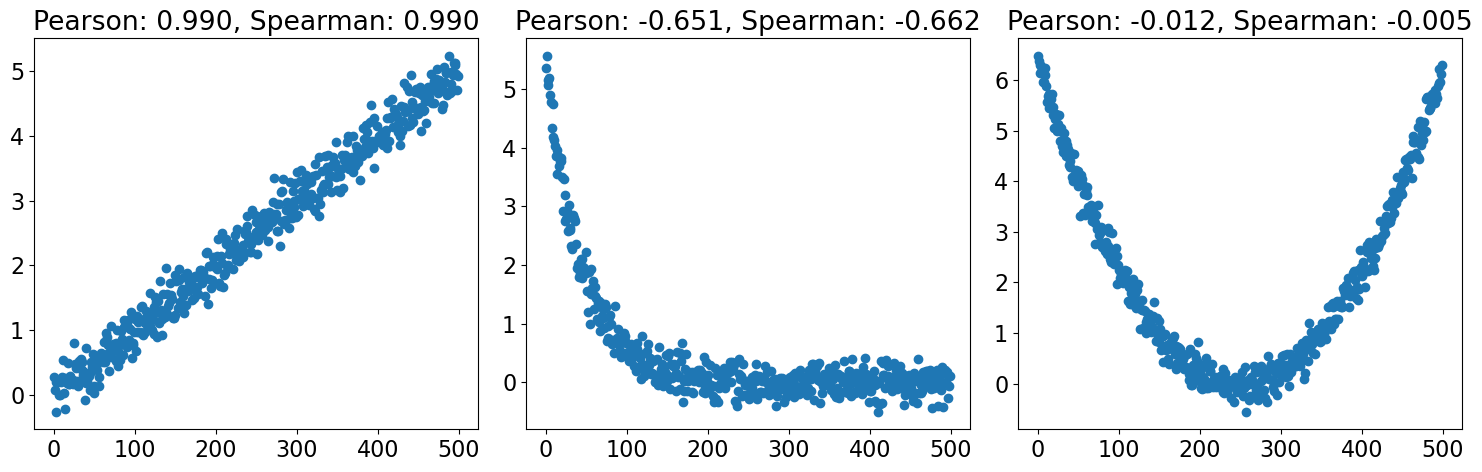

In [10]:
sigma=1./5

u = np.arange( 0,500 )

linear = u*0.01 + sigma*np.random.randn( *(u.shape) )
monotonic= 50*(0.8**(10 + u/10))+sigma*np.random.randn( *(u.shape) )
non_monotonic=(0.01*u-2.5)**2+sigma*np.random.randn( *(u.shape) )

fig,axes = plt.subplots(1,3,figsize=(15,5))

for i,y in enumerate( [ linear , monotonic , non_monotonic ] ):
    ax = axes[i]
    
    ax.scatter(u,y)
    ax.set_title('Pearson: {0:.3f}, Spearman: {1:.3f}'.format(
                                    stats.pearsonr(u,y)[0],##just like that
                                    stats.spearmanr(u,y)[0]))
plt.tight_layout()    
plt.show()

Going back to our real dataset 

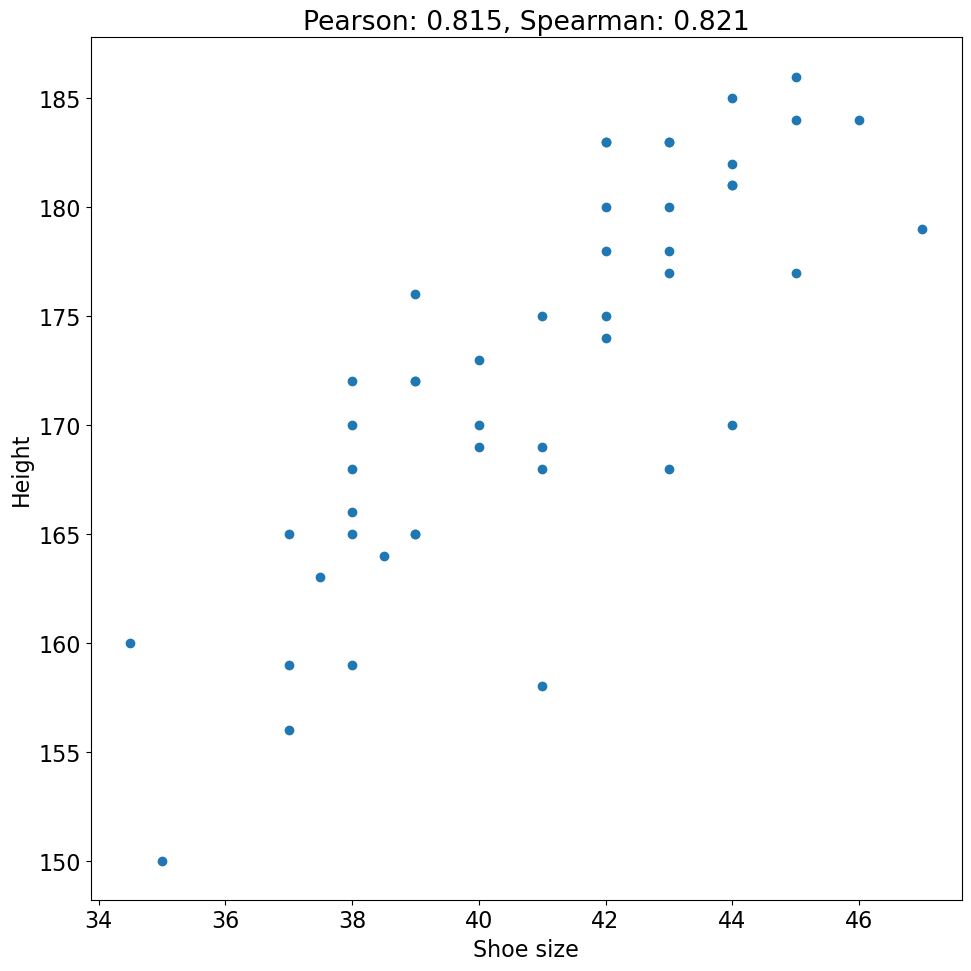

In [11]:
x=df['shoe_size']
y=df['height']
plt.scatter(x,y)
plt.title('Pearson: {0:.3f}, Spearman: {1:.3f}'.format(
                                    stats.pearsonr(x,y)[0],##just like that
                                    stats.spearmanr(x,y)[0]))
plt.xlabel('Shoe size')
plt.ylabel('Height')
plt.tight_layout()    
plt.show()



[back to the toc](#toc)

<br>

## 1.3. Significance of Pearson and Spearman correlation coefficient.  <a id='3'></a>


There are 3 main ways to evaluate the significance of $\rho$ (the coefficient of correlation) compared to zero. The most straightforward rely on a t-test to evaluate if $\rho$ is significantly different from 0.

Following a permutation  argument (so looking at a null model where you break data correlation/class by creating all the possible arrangements of your data), you can rationalize the usage of the following test statistic :

$$t=\rho\sqrt{\frac{n-2}{1-\rho^2}}$$

which follow a Student's t-distribution under the null hypothesis that $\rho=0$.


The other two ways to evaluate the significance of $\rho$ are :

- Do the permutation test yourself
- Transform the data using Fisher transformation ($F(\rho)=arctanh(\rho)$) to calculate a z variable (instead of a t-student variable), which is normally distributed under $H_0$ : $z=\sqrt{\frac{n-3}{1.06}}F(\rho)$


[back to the toc](#toc)

<br>

## 1.4 Kendall tau correlation coefficient (for fun)  <a id='4'></a>


You have already seen that you could define a correlation coefficient in multiple manners using multiple metrics : multiplicative distances to the means for Pearson, ranking distances between the two random variables for Spearman. For completeness let's rapidly present another way to measure correlation : Kendall tau.

Kendall tau is based on the concept of concordant or discordant pairs. A concordant pair is a pair of individual i and j, $i<j$, for which the order relation between the two random variables stands : either $x_i>x_j$ and $y_i>y_j$ or $x_i<x_j$ and $y_i<y_j$. Discordant pairs have opposite signs between x and y.

The coefficient is defined as follow:

$$\tau=\frac{\text{number of concordant pairs}-\text{number of discordant pairs}}{\frac{n(n-1)}{2}}$$

Obviously this coefficient is comprised between -1 and 1, 0 meaning no correlation (indeed there is a total of $\frac{n(n-1)}{2}$ unique pairs).

A rank version also exists (which is mathematically equivalent to the expression above):

$$\tau_{rank}=\frac{2}{n(n-1)}\sum_{i<j} sgn(x_i-x_j)sgn(y_i-y_j)$$

Both the Spearman and and Pearson correlation coefficent are relying on distances, which means they are sensitive to the intensity of the error term and to outliers.  Kendall tau is way less influenced by the scale of the variability since it relies only on an order relation.







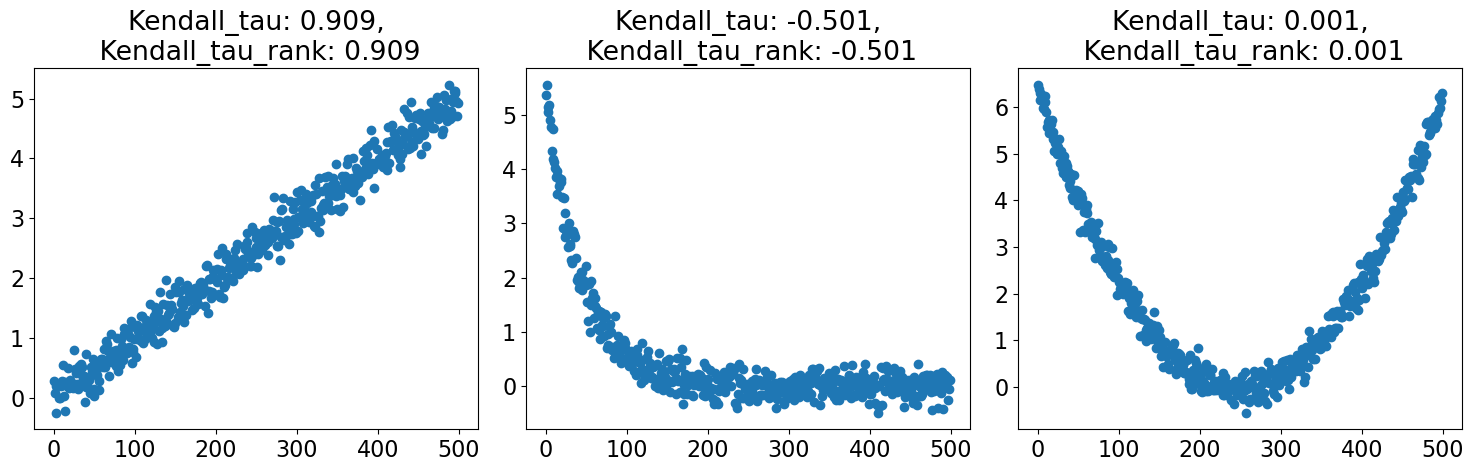

In [12]:
fig,axes = plt.subplots(1,3,figsize=(15,5))

for i,y in enumerate( [ linear , monotonic , non_monotonic ] ):
    ax = axes[i]
    
    ax.scatter(u,y)
    ax.set_title('Kendall_tau: {0:.3f},\n Kendall_tau_rank: {1:.3f}'.format(
                            stats.kendalltau(u,y)[0],
                            stats.mstats.kendalltau(u,y)[0]))

plt.tight_layout()    
plt.show()


[back to the toc](#toc)

<br>

# Exercise 01  <a id='5'></a>

Given the *etubiol* dataset, rank the best correlators of *height*.

Among these, which seem redundant to you (because of a high correlation)?

> If you work with a panda dataframe you can use (or not) the functionality `DataFrame.corr()` to calculate the pearson correlation between all the variable of the dataframe

**Important** you will have to restrict your computation to numerical columns in the dataframe. Here is some code to select them:

In [13]:
num_columns = df.columns[ df.dtypes != 'object' ]
num_columns

Index(['height', 'weight', 'shoe_size', 'R_wrist_girth', 'L_wrist_girth',
       'nb_siblings', 'height_M', 'height_F', 'nb_siblings_F', 'nb_siblings_M',
       'bmi'],
      dtype='object')

In [14]:
df[num_columns].head()

,height,weight,shoe_size,R_wrist_girth,L_wrist_girth,nb_siblings,height_M,height_F,nb_siblings_F,nb_siblings_M,bmi
0,183,72,42.0,17.0,16.6,2,170,174,5,1,21.5
1,183,68,43.0,17.0,16.0,1,170,178,4,2,20.3
2,182,73,44.0,18.5,18.0,2,168,181,3,5,22.0
3,175,66,41.0,17.0,17.0,2,156,178,4,7,21.6
4,158,42,41.0,14.0,14.0,2,156,178,4,7,16.8


correlation with numerical variables:

In [17]:
# %load -r -10 solutions/solution_04_corr.py


link with categorical variables:

In [20]:
# %load -r 11- solutions/solution_04_corr.py




[back to the toc](#toc)

<br>

## 1.5 Correlation and causation  <a id='6'></a>

"Correlation does not equal causation" is one of these [often](https://xkcd.com/552/) [repeated](https://www.explainxkcd.com/wiki/index.php/925:_Cell_Phones) [sentence](https://en.wikipedia.org/wiki/Correlation_does_not_imply_causation), but it is still true nonetheless.

Observing that A and B are correlated (linearly or otherwise) gives you **no information** about whether A causes B or B causes A. One may not cause the other at all (they might both be caused by another [unidentified process](https://xkcd.com/1138/)!).

Furthermore, even if a coefficient of correlation if very high, it might still be completely [spurious](https://www.tylervigen.com/spurious-correlations).

![spurious](images/spurious_chart.png)

It is thus important to always shed a critical eye on correlations and the conclusion we could be tempted to draw from them.


[back to the toc](#toc)

<br>

# 2. Linear regression  <a id='7'></a>


Now that we have defined correlation, we can see further ways to characterise the relationship between two variables.

The problem we are interested in is the following:

We measured a bunch of variables per individual, for many individuals. We are interested in the relationship between one of this variable that we will call the *response variable* ($Y$) and the other variables that we will call *covariables* ($X$). 
Of course our measurments are not perfect so there is some noise associated to it ($\epsilon$). In mathematical term we are interested in a class of problem that we can write as :

$\pmb{Y}=f(\pmb{X})+\epsilon$

The function $f$ is called the regression function, and today we will be interested in looking at a particular form of those function: **linear combination**.

A particular case of linear combination would be a single covariable with an intercept like :

$y_i=\beta x_i+c$

![linear_model1.png](images/linear_model1.png)

A more general case would have more covariables and would be written like:

$$f(\textbf{X}_i,\pmb{\beta})=\sum_{p} \beta_p x_{i,p}= \textbf{X}_{i}^{T}\pmb{\beta}$$

Where *$X_i$* is a vector of p covariables associated to point individual i.

Note that for now nothing is said about the nature of the $x_{i,p}$, for example some could be constant instead of being a variable and thus you could go back to a more specific affine function (like $\beta x+c$).

So of course now the game become to best choose the vector of parameters $\pmb{\beta}$. For that there are two main methods (sorry Bayesian people...):
- Least Square fit
- Maximum Likelihood

We will discuss both those methods. Least square fit is the most intuitive and easy to get a hold on, so hopefully you will leave this class with a rather good understanding of it. Maximum likelihood is a bit more advanced in terms of the concepts it utilizes, but being introduce to it will allow you to manipulate cool concepts that you will need by the end of this notebook and if you keep learning about statistics in general. 

Underlying those different methods, there are different models:

- Linear models
- Generalized linear models

The way we wrote the function linking $Y$ to $X$ above, have the noise term $\epsilon$ outside of the function. So one would say that this function only try to represent the mean of the response variable $Y$ along the curve, and as importantly, it does it looking at linear function. 
. This is what we actually do in the framework of Linear models : we only aim to fit the mean response using linear functions.

Generalized linear models, on the other hand, are more flexible : they allow us to transform the mean response and to fit that transformed response with a linear model. It is very powerfull, as now we could better modeled response variable with broader properties (count data, categorical data etc....), but significantly more complicated and so we will not talk about those methods here.


# Least square


[back to the toc](#toc)

<br>

## 2.1. Presentation  <a id='8'></a>


For clarity let's define once for all some variables : we have a sample of size n, for each individual on this sample there are p+1 measurments, p covariables and one response variable. 

In the least square method we are interested in making the smallest overall distance error between our model and the response variable. 
Typically we want to find the $\beta$ that minimizes:

$S(\pmb\beta)=\sum_i (y_i-f(\textbf{X},\pmb{\beta}))^2=\sum_i \epsilon_i^2$

in mathematical terms you are looking for 

$\hat{\pmb\beta}=\text{arg min}_{\pmb\beta}S(\pmb\beta)$

Here the sum is over i, which counts the number of individuals.

> The hat $\hat{.}$, is a notation we use to denote our estimate of the true value of something. So in that sense $\hat{\pmb\beta}$ is the estimate of the "real" coefficient values, and $\hat{Y}$ is the estimation of $Y$ given by our model (also called the model predictions).

Let's try to represent this:

First a real case scenario just to show case the outcome of what we are trying to do ultimately

Basically we want to end up with thefollowing graph and outputs.

slope also called beta in our notation=  2.4323792016806713
intercept also called c in our notation=  72.89751838235297


Text(0, 0.5, 'height')

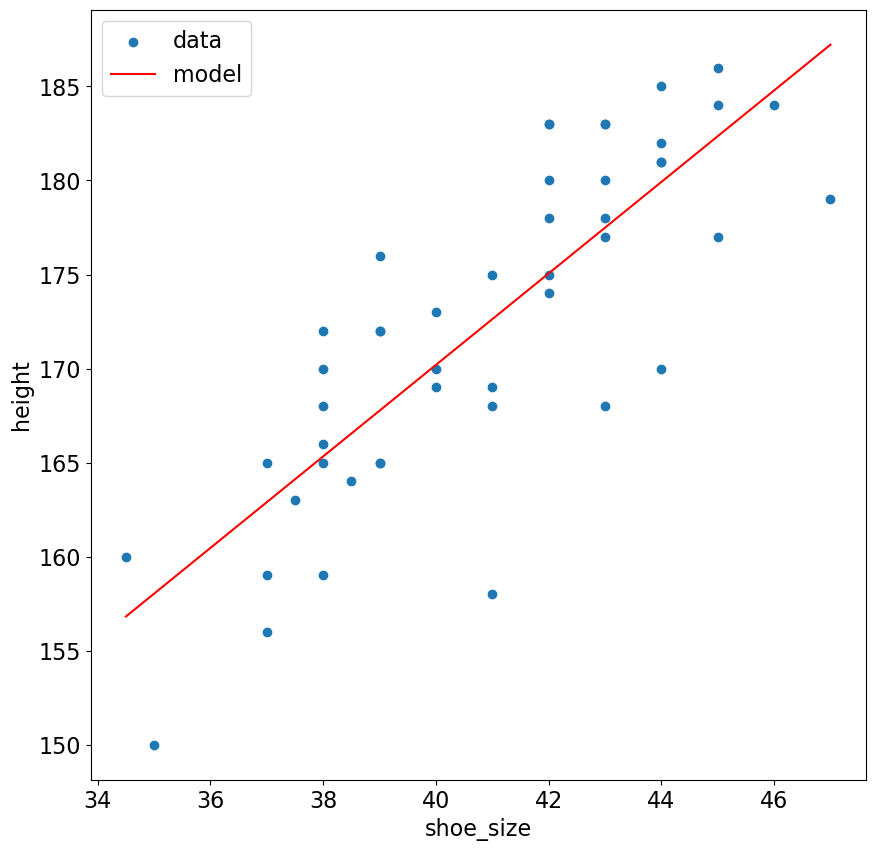

In [21]:
x=df['shoe_size']
y=df['height']


plt.scatter(x,y,label='data')
slope , intercept , r , pval , stderr = stats.linregress(x,y)
#linear regression explaining y (height) thanks to x (shoe_size)

print(r"slope also called beta in our notation= ",slope)
print("intercept also called c in our notation= ",intercept)

#now that we have the outcome iof the regression which is in this case a slope and
#an intercept we can calulate what the model will predict as height given a shoe_size
yPredict = x.sort_values() * slope + intercept 
#the outcome of the regression is this red line
plt.plot( sorted( x ) , yPredict , color = 'red',label='model')
plt.legend(loc='best')
plt.xlabel('shoe_size')
plt.ylabel('height')

What does Least square method do to end up with this line? Well let's see it on some simple mock data

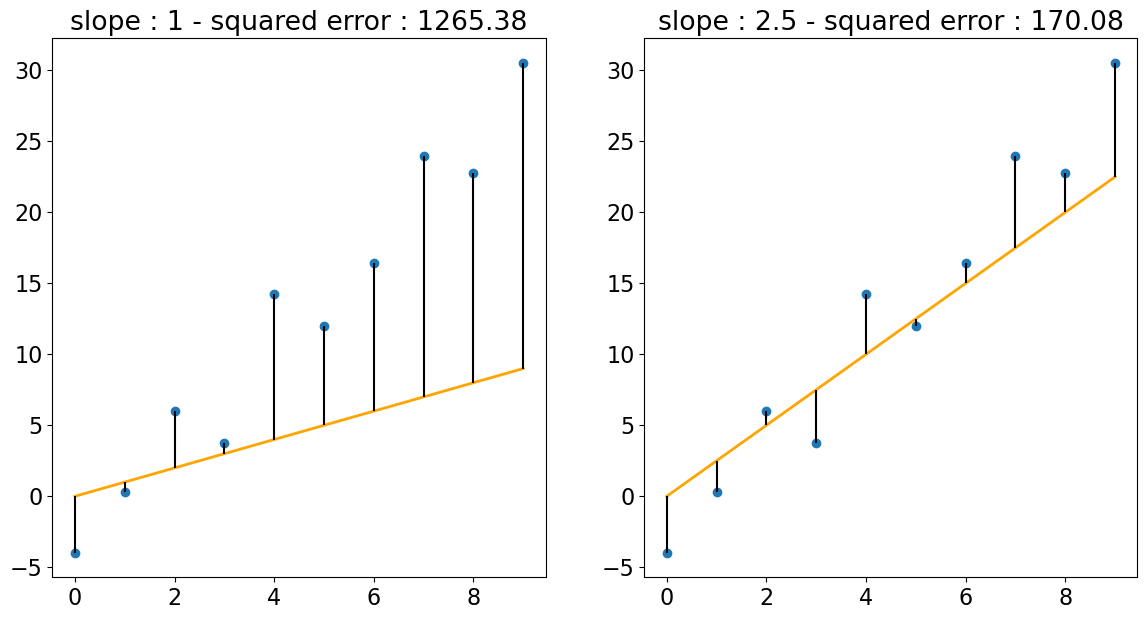

In [22]:
from matplotlib import collections  as mc

## let's create some data to plot
slopeReal = 3
noise = 3
x = np.arange(10)
y = slopeReal * x + noise * np.random.randn(len(x)) # y = beta * x + some noise (no intercept here)
## alternatively we could have:
# x= df['shoe_size'] 
# y= df['height']
## although note that in that case we also need an intercept. you can try 70



# The challenge of least square regression is to find the slope that minimizes the squared error
# let's try two possible values for the slope 
estimatedSlopes = [1,2.5]

fig, ax = plt.subplots(ncols=len(estimatedSlopes) , figsize = (14,7))

for i,slopeEstimate in enumerate(estimatedSlopes):
    yPredicted = slopeEstimate * x # prediction of y given the estimated slope and values of x

    # error of the prediction
    predictionSquaredError = sum( ( yPredicted - y )**2 )

    ax[i].plot(x,y, 'o')
    ax[i].plot(x,yPredicted, color='orange' , linewidth=2)

    # now, let's represent the fitting error as segments between real and estimated values
    Real = [i for i in zip(x,y)]
    Predicted = [i for i in zip(x,yPredicted)]
    lc = mc.LineCollection(zip(Real,Predicted) , colors='black')
    ax[i].add_collection(lc)

    ax[i].set_title('slope : {} - squared error : {:.2f}'.format(slopeEstimate,predictionSquaredError) )


all the slopes tested [0.   0.06 0.12 0.18 0.24 0.3  0.36 0.42 0.48 0.54 0.6  0.66 0.72 0.78
 0.84 0.9  0.96 1.02 1.08 1.14 1.2  1.26 1.32 1.38 1.44 1.5  1.56 1.62
 1.68 1.74 1.8  1.86 1.92 1.98 2.04 2.1  2.16 2.22 2.28 2.34 2.4  2.46
 2.52 2.58 2.64 2.7  2.76 2.82 2.88 2.94 3.   3.06 3.12 3.18 3.24 3.3
 3.36 3.42 3.48 3.54 3.6  3.66 3.72 3.78 3.84 3.9  3.96 4.02 4.08 4.14
 4.2  4.26 4.32 4.38 4.44 4.5  4.56 4.62 4.68 4.74 4.8  4.86 4.92 4.98
 5.04 5.1  5.16 5.22 5.28 5.34 5.4  5.46 5.52 5.58 5.64 5.7  5.76 5.82
 5.88 5.94 6.  ]
slope estimate with the smallest error :  2.82


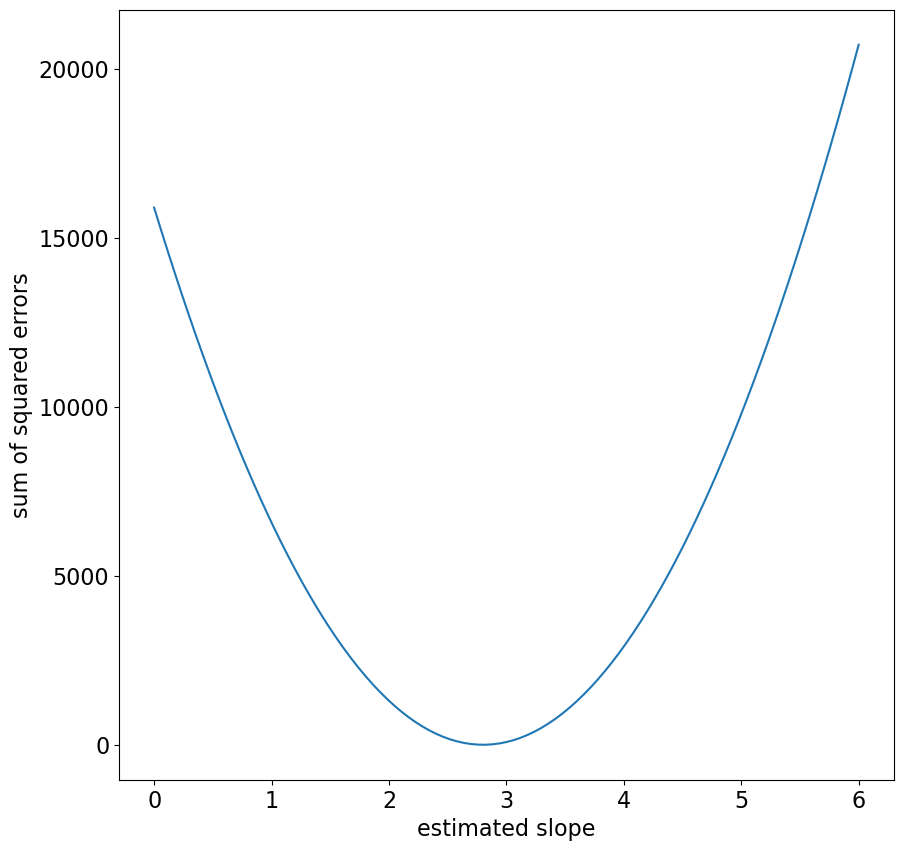

In [23]:
# to find the best value for the slope, we could try a lot of them :
possibleSlopes = np.linspace(0,6,101)
print('all the slopes tested',possibleSlopes)
errors = []
for sl in possibleSlopes: # we compute the sum of squared error for each slopes
    yPred = sl*x
    errors.append( sum( yPred - y )**2 )

plt.plot(possibleSlopes , errors )
plt.xlabel('estimated slope')
plt.ylabel('sum of squared errors')
print( 'slope estimate with the smallest error : ', possibleSlopes[np.argmin(errors)] )

While we could use various optimization algorithms to find the best value for $\beta$, 
when the system is overdetermined (*i.e.*, you have more points than coefficients $\beta_i$) an analytical solution exists. It is of the form:

$$\hat{\pmb\beta}=(\pmb X^T \pmb X)^{-1}\pmb X^T \pmb Y$$






[back to the toc](#toc)

<br>

## 2.2. Underlying hypothesis  <a id='9'></a>

There are a couple of important hypothesis behind this method:

- **Correct specification** : have a good incentive for the function you use
- **Strict exogeneity** : the errors are centered around the true value of y
- **No linear dependance** : you can not reconstruct one of your covariable by summing a subset of your covariables with some set of constant weights 
- **Spherical errors**: 
    - Homoskedasticity : the spread of the error is the same along the curve (for example not true for counts data).
    - No autocorrelation : error are not correlated along the curve.

Text(0.5, 1.0, 'heteroskedasticity')

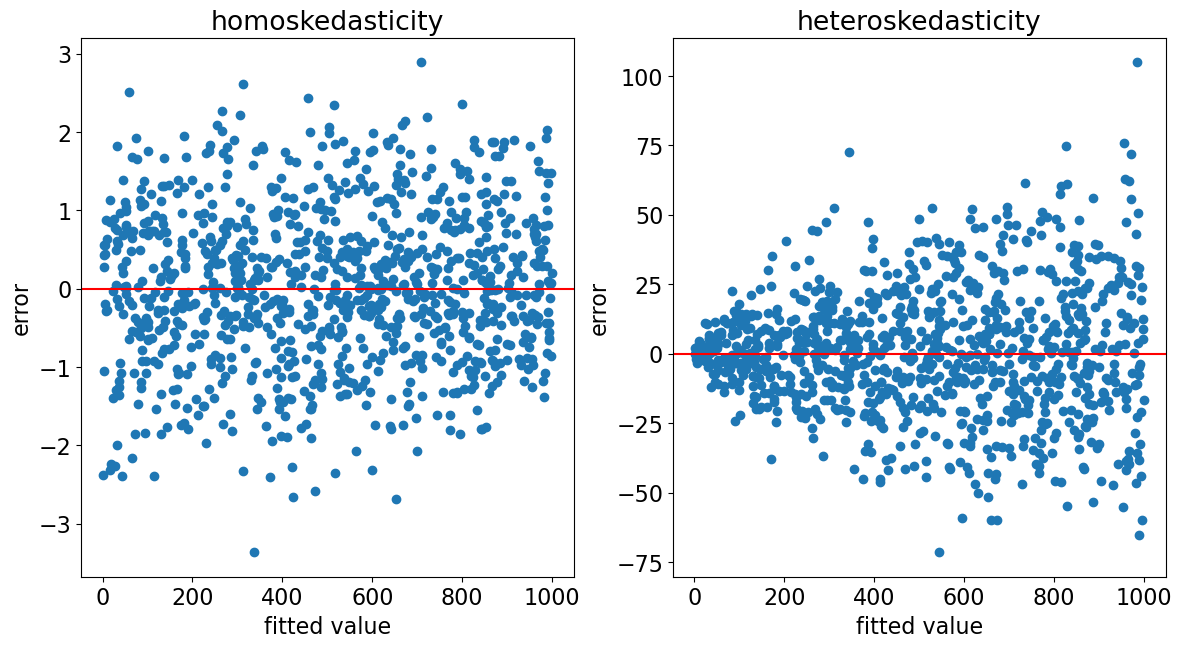

In [24]:
x = np.random.random(1000)*1000
y_homo = x + np.random.randn(*x.shape)
y_hete = np.random.poisson(lam=x)

y_error_homo = y_homo - x
y_error_hete = y_hete - x

fig,ax = plt.subplots(1,2,figsize=(14,7))
ax[0].scatter(x,y_error_homo)
ax[0].axhline(y=0,color='red')
ax[0].set_xlabel("fitted value")
ax[0].set_ylabel("error")
ax[0].set_title("homoskedasticity")

ax[1].scatter(x,y_error_hete)
ax[1].axhline(y=0,color='red')
ax[1].set_xlabel("fitted value")
ax[1].set_ylabel("error")
ax[1].set_title("heteroskedasticity")


The linear dependance part has to do with the part of the exercise where we look at highly correlated covariables. 
If you want to produce a good model for prediction then be careful about that point. You can have a feeling of what the problem is by imagining that 2 covariables are actually identical to each other: there is no unique way to associate a weight to them... Also then you have 1 variable which bring nothing new to the modeling... so it is superfluous. This is why later on we will work on a restricted part of the covariables.

If your goal is not really to produce a predictive model but more to infer the size effect of some covariables on your target variable, then it is not too crucial. Just remember that if this is what you want there are other steps to take, that are far beyond the scope of this course, and which are related to the field of causal inference.

Normality is not strictly needed for Least Square fitting, neither for the variables nor for their errors. 
However you may need that hypothesis downstream in your analysis, for instance when using a test statistic.

If the errors are normally distributed, then Least Square fitting and Maximum Likelihood are equivalent, showing that your method for choosing $\pmb\beta$ is efficient and sound.

We will quickly present the Maximum Likelihood equivalent as it is both a very useful technic and helps broadening linear models to Generalized Linear Models.

Finally, within that set of constraints and even if the method is called Linear Models, it is possible to fit polynomials of a degree bigger than 1. To do so you just have to precompute the monomials and add them to your set of covariables.

For example :

$y=\beta x +c$ is a linear combination of x

$y=\beta_{1}x+\beta_{2}x^{2}+\beta_{3}x^{3}$ is still a linear combination of features (covariables) x, $x^{2}$ and $x^{3}$, and **X** becomes {$x,x^2,x^3\}


[back to the toc](#toc)

<br>

## 2.3. Goodness of fit  <a id='10'></a>

To have an idea of how good your fit is, you can either directly use the Mean Squared Error (MSE) or the adjusted coefficient of determination $\pmb R^2_a$.

The MSE is defined as follow:

<br>

$$MSE=\frac{\sum (y_i-\hat{y_i})^2}{n-2}$$ 
and accounts for what your model is missing. 
That could be the simple inherent variance induced by the noise term or the noise term and a missing term that your model doesn't take into account. By its nature, this metric makes it hard to compare between different hypothetical fitting models or different dataset.

A better normalized metric is the **adjusted coefficient of determination $\pmb R^2_a$**. 
The adjusted part is very necessary when we work in the context of multiple linear regression (more than one covariable). 

Let's start by defining the coefficient of determination $\pmb R^2$. 
This coefficient partitions the variance present in your data between what is taken into account by your model and what is not.

$$R^2=1-\frac{SSE}{SST}$$, where SSE is the sum of squared errors ($\sum_i (y_i-\hat{y_i})^2$) and SST in the sum of squares total ($\sum_i (y_i-\bar{y})^2$)

For the adjusted coefficient of determination you have to take into account that SSE and SST don't have the same degree of freedom and you should adjust for that.

$$R^2_a=1-\frac{n-1}{n-p}(1-R^2)$$, with $p$ the number of covariables and $n$ the number of individuals.

> Note : you can see that when there is only one covariable then $R^2_a = R^2$

[back to the toc](#toc)

<br>

## 2.4. Confidence interval and test statistics  <a id='11'></a>

After your fitting, you would probably like to know the confidence interval for each of your estimated $\beta$, as well as if they are truly necessary (significantly different from zero). 
For both **you can't truly do anything without making an hypothesis about the statistic of the noise** : here comes the part where assuming your noise to be normally distributed ($N(0,\sigma^2)$) becomes important, but potentially wrong too.

For the confidence interval, if you have an infinite amount of data, and your noise distribution is not heavytailed, you can show that the estimators are well described by a normal statistic (there is convergence in the distribution so that $(\hat{\pmb\beta}-\pmb\beta)\rightarrow N(0,\sigma^2 (\pmb X^T \pmb X)^{-1})$). 
So for big amount of points relative to the number of estimated parameters, you are not making a big mistake by writting:

$$\beta_p \in [\hat{\beta_p} \pm z_{1-\frac{\alpha}{2}}\sqrt{\hat{\sigma}^2 [(\pmb X^T \pmb X)^{-1}]_{p,p}}]$$

If you don't have a huge amount of data you need to show that you have an incentive about your noise statistic to use these kind of confidence intervals (some libraries that we are going to use can do that for you!).


For the significance of the coefficients, **if you know that your noise is normally distributed then you can use a t-test**.


[back to the toc](#toc)

<br>

### Examples:  some linear regression examples 

#### Affine

This is typically the case where we would like to describe height = $\beta$ shoe_size + c

Here we look at a model y=1+3*x

epsilon 0
fit param c= 1.000 beta= 3.000
true param c= 1.000 beta= 3.000

epsilon 1
fit param c= 1.101 beta= 3.147
true param c= 1.000 beta= 3.000

epsilon 10
fit param c= 0.723 beta= 3.970
true param c= 1.000 beta= 3.000



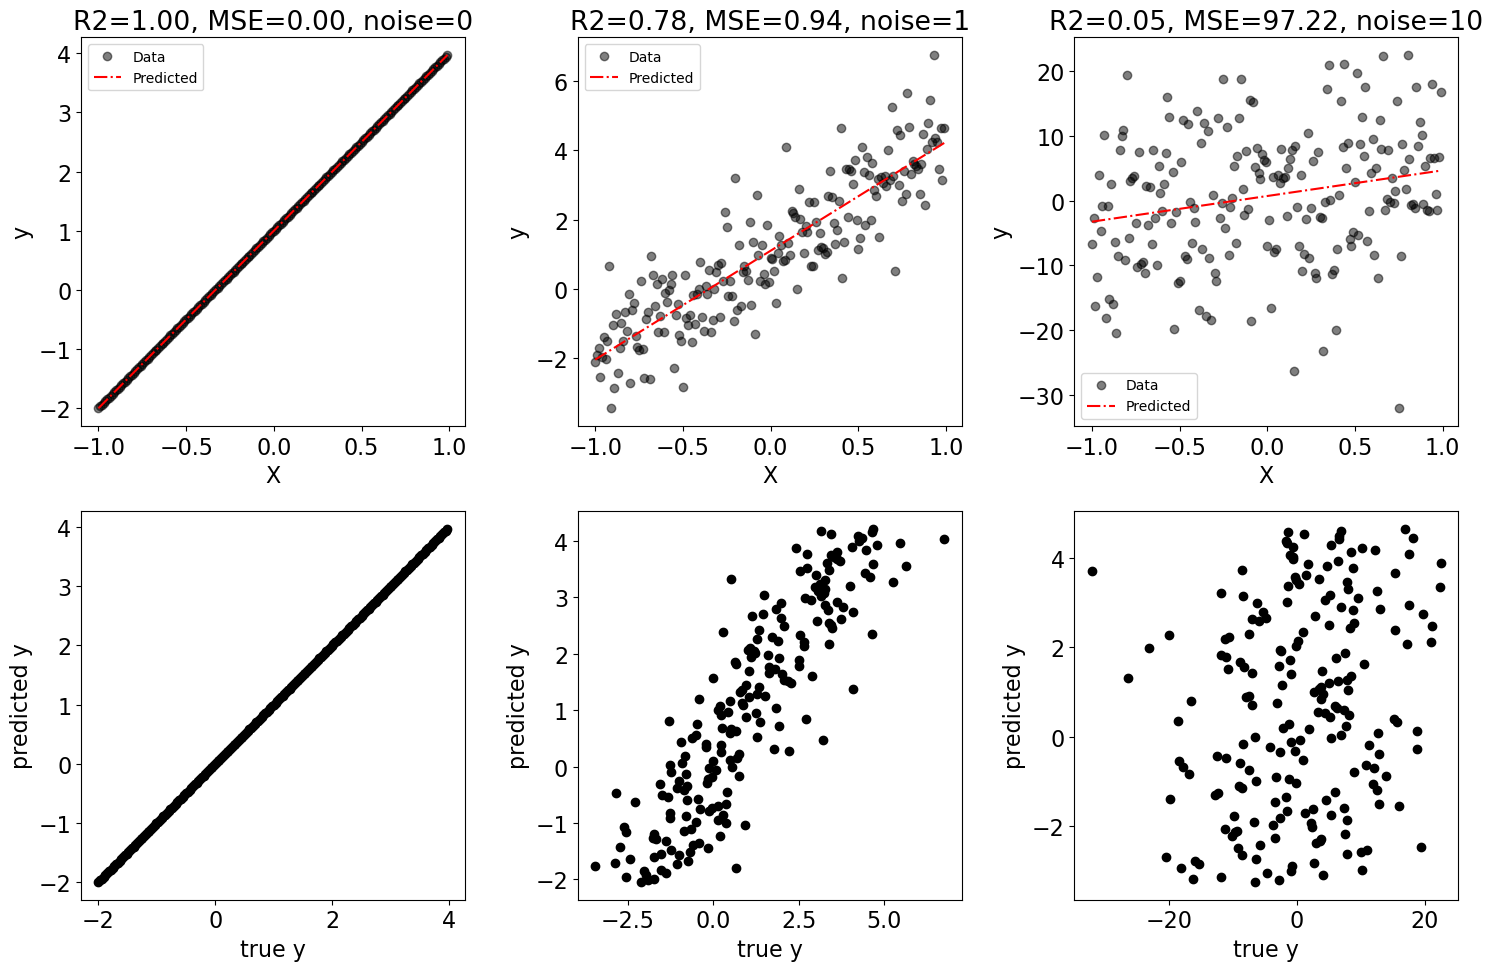

In [25]:
import statsmodels
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

X=np.array(np.arange(-1,1,10**-2))
fig,ax=plt.subplots(2,3,figsize=(15,10))

for k,epsilon in enumerate([0,1,10]):
    
    y = 1+3*X + epsilon* np.random.randn(  len(X) )
    
    ## creating a dataframe with the data
    X1 = sm.add_constant(X)##adding the intercept    
    df_=pd.DataFrame(X1,columns=['c','x'])
        
    model = sm.OLS( y , df_[['c','x']])##defining an Ordinary Least Square variable
    results = model.fit()##fitting it
    y_predict=results.predict(X1)# predict back what your target variable would be in that model
    R2=r2_score(y,y_predict)#evaluate R2
    MSE=mean_squared_error(y,y_predict)#evaluate MSE

    ## plotting the data and model
    ax[0,k].plot(X,y,'ko',label='Data',linewidth=10,alpha=0.5)
    ax[0,k].plot(X,y_predict,'r-.',label='Predicted')
    ax[0,k].legend(loc='best',fontsize=10)
    ax[0,k].set_title('R2={0:.2f}, MSE={1:.2f}, noise={2}'.format(R2,MSE,epsilon))
    ax[0,k].set_xlabel('X')
    ax[0,k].set_ylabel('y')
    
    ## plotting predicted value versus real value is a good way to visualize a fit
    ax[1,k].plot(y,y_predict,'ko')
    ax[1,k].set_xlabel('true y')
    ax[1,k].set_ylabel('predicted y')
    print('epsilon',epsilon)
    print('fit param c= {0:.3f} beta= {1:.3f}'.format(results.params['c'],results.params['x']))
    print('true param c= {0:.3f} beta= {1:.3f}'.format(1,3))
    print()
plt.tight_layout()
plt.show()
    
    

Let's see what happened if we miss specify the polynomial degree :

epsilon 0
fit param c= 1.000 beta1= 3.000 beta2= 0.000 beta3= -0.000
true param c= 1.000 beta= 3.000

epsilon 1
fit param c= 0.800 beta1= 3.436 beta2= 0.366 beta3= -0.695
true param c= 1.000 beta= 3.000

epsilon 10
fit param c= 1.886 beta1= 4.821 beta2= 0.301 beta3= -2.916
true param c= 1.000 beta= 3.000



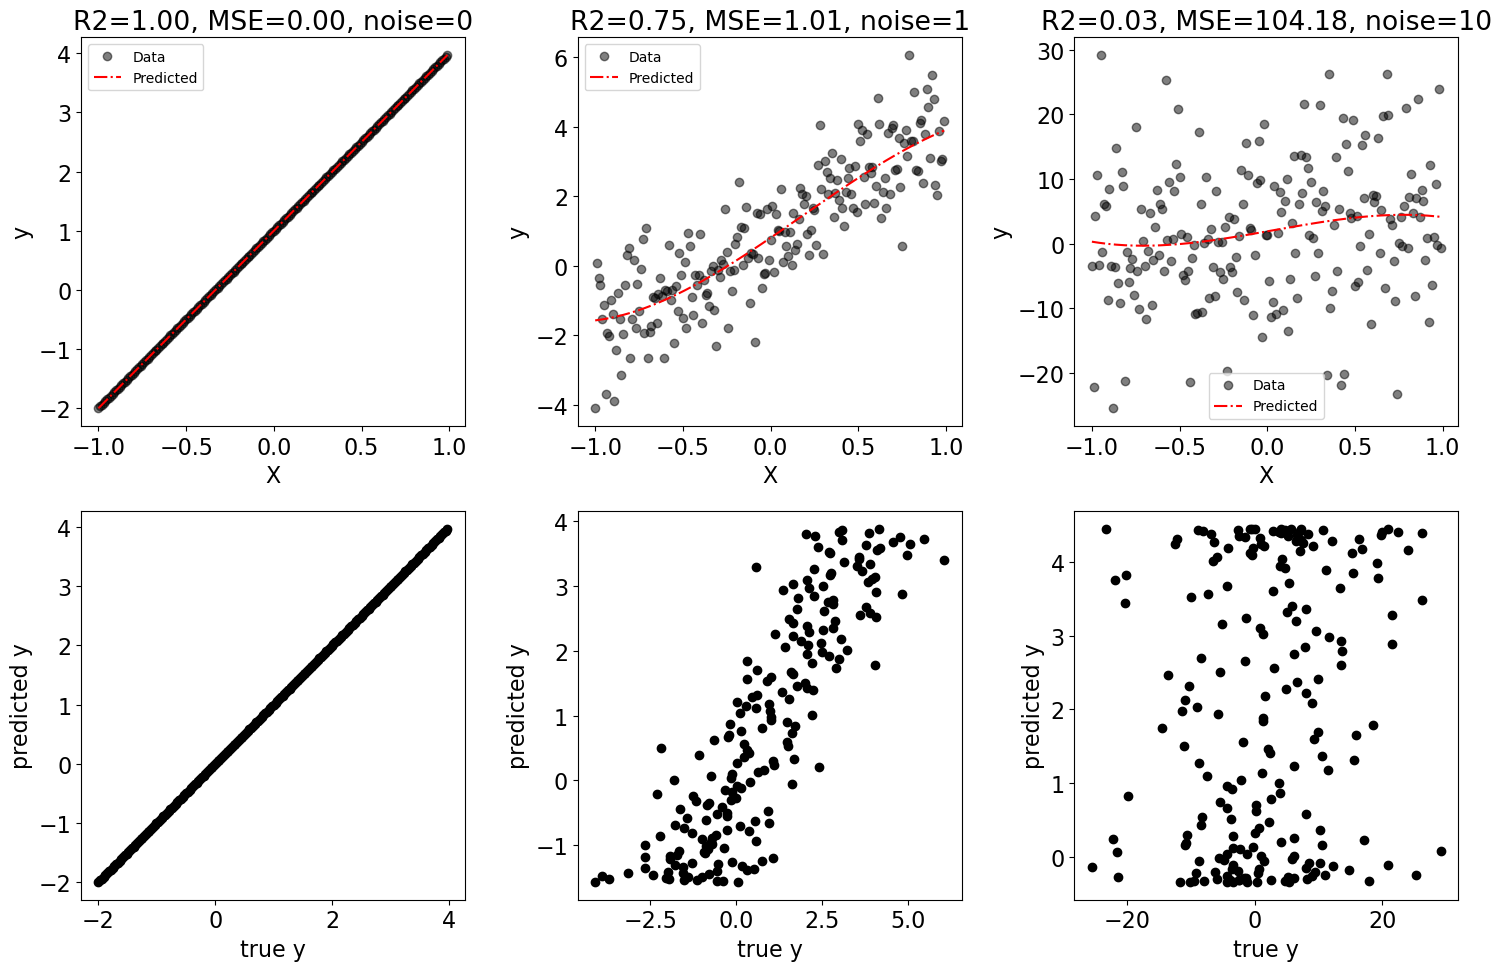

In [26]:
X=np.array(np.arange(-1,1,10**-2))
fig,ax=plt.subplots(2,3,figsize=(15,10))

for k,epsilon in enumerate([0,1,10]):

    y = 1+3*X + epsilon* np.random.randn(  len(X) )
    
    X1 = np.column_stack((X, X**2,X**3))
    X1 = sm.add_constant(X1)##adding the intercept
    
    df_=pd.DataFrame(X1,columns=['c','x','x²','x³'])
    
    model = sm.OLS( y , df_[['c','x','x²','x³']])##defining an Ordinary Least Square variable
    results = model.fit()##fitting it
    y_predict=results.predict(X1)# predict back what your target variable would be in that model
    R2=r2_score(y,y_predict)#evaluate R2
    MSE=mean_squared_error(y,y_predict)#evaluate MSE


    ax[0,k].plot(X,y,'ko',label='Data',linewidth=10,alpha=0.5)
    ax[0,k].plot(X,y_predict,'r-.',label='Predicted')
    ax[0,k].legend(loc='best',fontsize=10)
    ax[0,k].set_title('R2={0:.2f}, MSE={1:.2f}, noise={2}'.format(R2,MSE,epsilon))
    ax[0,k].set_xlabel('X')
    ax[0,k].set_ylabel('y')
    
    ax[1,k].plot(y,y_predict,'ko')
    ax[1,k].set_xlabel('true y')
    ax[1,k].set_ylabel('predicted y')
    print('epsilon',epsilon)
    print('fit param c= {0:.3f} beta1= {1:.3f} beta2= {2:.3f} beta3= {3:.3f}'.format(results.params['c'],results.params['x'],results.params['x²'],results.params['x³']))
    print('true param c= {0:.3f} beta= {1:.3f}'.format(1,3))
    print()
plt.tight_layout()
plt.show()

On the height datset

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     89.30
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.97e-12
Time:                        17:08:10   Log-Likelihood:                -142.98
No. Observations:                  47   AIC:                             290.0
Df Residuals:                      45   BIC:                             293.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     72.8975     10.550      6.910      0.0

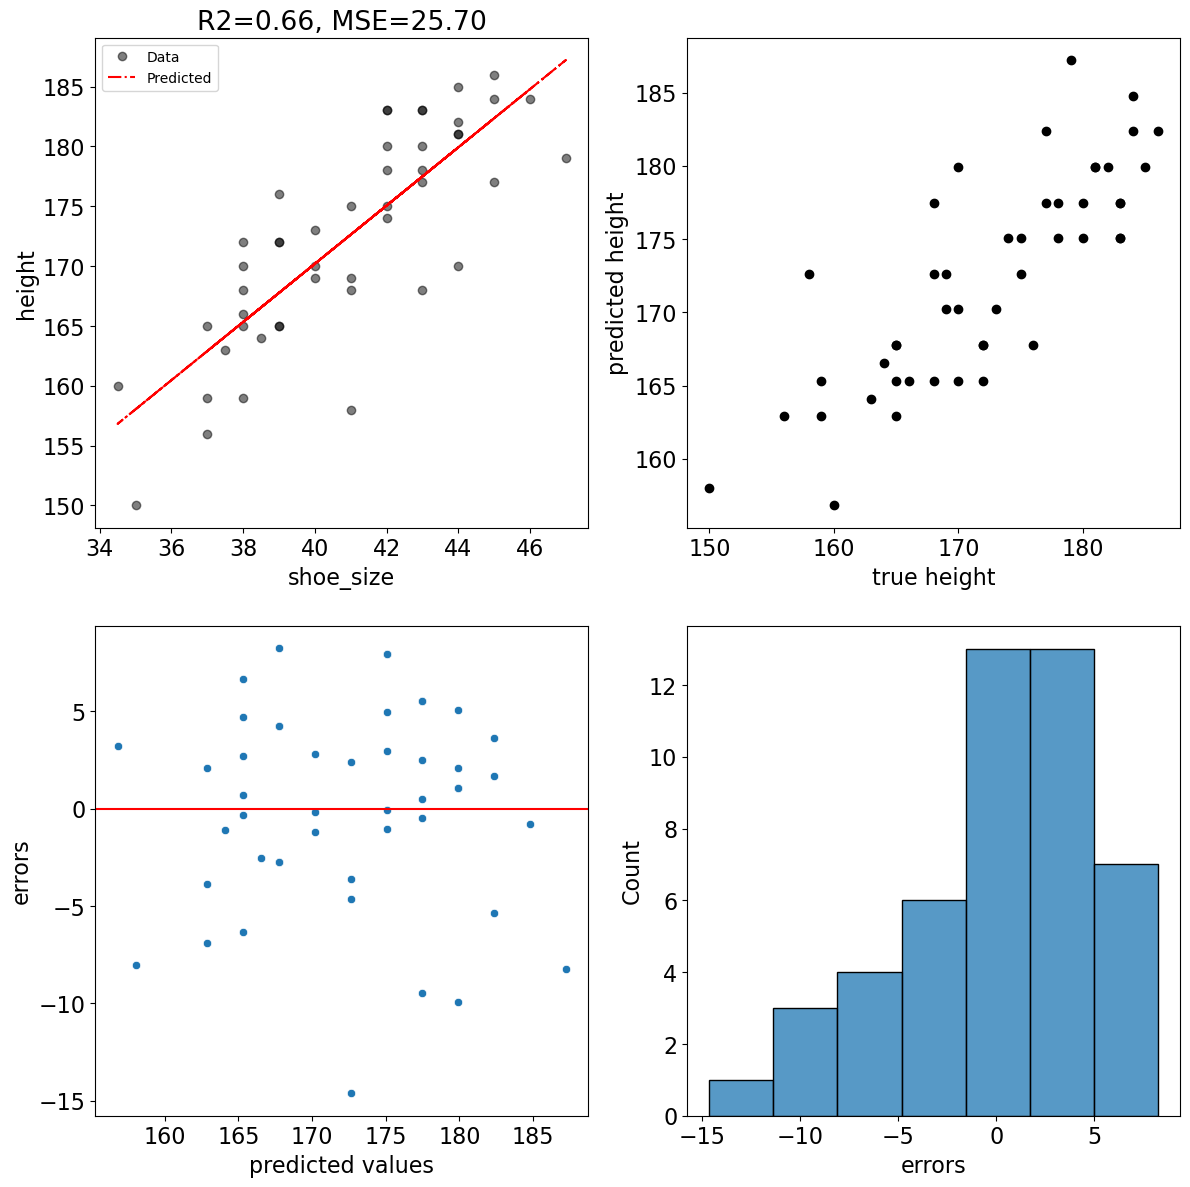

In [27]:
import statsmodels.formula.api as smf
model = smf.ols(formula='height ~ shoe_size', data=df)

results = model.fit()#we do the actual fit
y_predict=results.predict(df)# predict back what your target variable would be in that model
R2=r2_score(df['height'],y_predict)
MSE=mean_squared_error(df['height'],y_predict)


fig , ax = plt.subplots(2,2, figsize=(14,14))

O = np.argsort(df['height'])
ax[0][0].plot(df['shoe_size'],df['height'],'ko',label='Data',linewidth=10,alpha=0.5)
ax[0][0].plot(df['shoe_size'][O],y_predict[O],'r-.',label='Predicted')
ax[0][0].legend(loc='best',fontsize=10)
ax[0][0].set_title('R2={0:.2f}, MSE={1:.2f}'.format(R2,MSE))
ax[0][0].set_xlabel('shoe_size')
ax[0][0].set_ylabel('height')
  

ax[0][1].plot(df['height'],y_predict,'ko')
ax[0][1].set_xlabel('true height')
ax[0][1].set_ylabel('predicted height')

sns.scatterplot(x=y_predict,y=results.resid , ax=ax[1][0]) # plot the errors along x
ax[1][0].axhline(0,color='red')
ax[1][0].set_ylabel('errors')
ax[1][0].set_xlabel('predicted values')
sns.histplot(results.resid , ax=ax[1][1]) # plot an histogram of the errors
ax[1][1].set_xlabel('errors')

print(results.summary())
print(results.resid.describe())

Let's go at these panels one by one.

In [28]:
print(results.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     89.30
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.97e-12
Time:                        17:08:15   Log-Likelihood:                -142.98
No. Observations:                  47   AIC:                             290.0
Df Residuals:                      45   BIC:                             293.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         


The first panel gives you an overview of the fit quality:
* You recognize the good old **$R^2$** and **$R_a^2$**
* The **F-statistic** and its associated P-value (**Prob (F-statistic)**) tests the hypothesis that all the coefficients are 0 (under a normality assumption)
* **Log-likelihood** (normality assumption + this is the next big part so keep it on a corner of your mind)
* AIC and BIC, respectively **Aikike Information Criterion** and **Bayesian Information Criterion** are used (like the log-likelihood) for model comparison. You can use them to compare non nested models. However they are, from my point of view less interpretable in the sense of what a threshold that you will put on those criterion means.

In [29]:
print(results.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     72.8975     10.550      6.910      0.000      51.648      94.147
shoe_size      2.4324      0.257      9.450      0.000       1.914       2.951


The second panel presents the coefficient values and associated statistics.
 * **const** is the intercept. It represents the value of the response variable when all covariable are at 0.
 * **shoe_size** is the coefficient of the $shoe\_size$. It represents the increase of the response variable when $shoe\_size$ increases by 1.

Regarding the columns:
 * **std err** : standard errors of the estimated coefficients.
 * **t** : t-test statistics.
 * **P>|t|** : p-values of the t-test testing if the coefficient is significantly different from 0.
 * **\[0.025 0975\]** : 95% confidence interval around the coefficient

Be careful with this **t-test which again makes the assumption that errors are normally distributed**, same for the standard error and the 95% confidence interval.

In [30]:
print(results.summary().tables[2])

Omnibus:                        4.355   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.113   Jarque-Bera (JB):                3.610
Skew:                          -0.675   Prob(JB):                        0.164
Kurtosis:                       3.137   Cond. No.                         573.


The third panel is a summary of a few statistical tests that will give you a sense of how all of the hypothesis needed for OLS are plausible:
* **Omnibus and Prob(omnibus)**: this is a test for normality of residuals. Low P-values means that your linear model is not adapted
* **Durbin-Watson** : tests autocorrelation in the error terms (2 is no autocorrelation, less than 1 is bad)
* **Jarque-Bera** : tests if the [skewness](https://en.wikipedia.org/wiki/Skewness) and [kurtosis](https://en.wikipedia.org/wiki/Kurtosis) of your errors are looking like a normal distribution. If the Pvalue is high then they look normal.
* **Condition Number** : tries to evaluate dependence between the co-variables. Close to infinity ($\gt 10^{15}$) mean there is a linear relationship between some co-variables (you can read more on this [here](https://medium.com/@docintangible/multicollinearity-in-pythons-statsmodels-ols-vs-r-s-lm-6fc9a994154c))

There is one important hypothesis of OLS which is missing from this summary : **homoskedasticity**.

Thankfully, statsmodels provide several tests for this as well, we will use White's test, whose null hypothesis is homoscedasticity:

In [31]:
from statsmodels.stats.diagnostic import het_white

LMstat , LMpval , Fstat , Fpval = het_white( results.resid , model.data.exog )
print("White test for heteroscedasticity p-value:" , LMpval)

White test for heteroscedasticity p-value: 0.9369363029340552


**Mini-exercise : what is your conclusion on the $shoe\_size$ model based on these results ?**


<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em;padding: 0.5em; cursor: pointer;"><summary>👁 View solution </summary>

We look first at the assumptions:
 * The heteroskedasticity test has a high p-value *and* the plot of error vs. predicted values does show obvious heteroskedasticity -> **homoskedasticity is not rejected**
 * Durbin-Watson value is close to 2 -> **no autocorrelation**
 * There is no multicollinarity between predictors between there is only one predictor here (Cond. No. < 1 000)

So the important assumptions of the linear model seem respected.

We can also look at the normality of residuals:
 * skew close to 0 and kurtosis close to 3 (the reference values for a normal distribution)
 * p-value of the Omnibus and Jarque-Bera test are > 0.05 (their null hypothesis is normality)
Consequently, we do not reject the hypothesis of normality of residuals (but we don't have that many point, so the powers of these tests is not high), so we may tentatively interpret the t-tests around the parameter values.

Model interpretation:
 * Adjusted R-squared: 0.657
     * Prob (F-statistic): 2.97e-12 -> the R-squared is significantly different from 0
 * intercept: 72.9 
     * 95% confidence interval (51.6-94.147) -> the intercept is significantly different from 0
 * shoe_size: 2.4 with 95% confidence interval (1.9-3.0)
     * 95% confidence interval (1.9-3.0) -> the effect of shoe size is significantly different from 0
 
The model explain ~65% of the variance in height (that is what the R-squared means), shoe size shows a significant association: an increase of 1.0 on shoe size is associated with an estimated increase in height of 2.4 (95% confidence interval : 1.9-3.0).

 


</details>


---

## 📝 Summary of Section 2: Linear Regression

In this section, we built up the full workflow of simple linear regression:

1. **Presentation (2.1)** — We framed the regression problem as finding the best-fitting linear function $\hat{Y} = X\hat{\boldsymbol{\beta}}$ that minimises the sum of squared errors.

2. **Underlying hypotheses (2.2)** — A valid OLS fit relies on several assumptions: correct model specification, strict exogeneity, no multicollinearity, and *spherical errors* (homoskedasticity + no autocorrelation). Violating these can invalidate both the fit and the inference.

3. **Goodness of fit (2.3)** — We measured fit quality with the MSE and the adjusted $R^2_a$, which penalises unnecessary extra parameters.

4. **Confidence intervals & test statistics (2.4)** — Once we assume normally distributed noise, we can attach standard errors, 95% confidence intervals, and p-values to each estimated coefficient $\hat{\beta}_p$, and use the F-statistic to test whether the model as a whole explains any variance.

> **Key take-away:** a high $R^2$ is necessary but not sufficient. Always inspect residual plots and the diagnostic tests (Omnibus, Durbin–Watson, Jarque–Bera, White's test) before interpreting coefficients.

---

### ✏️ Exercise 02 — Diagnosing a regression model <a id='E02'></a>

Using the *etubiol* dataset, fit a linear model of `height` on `bmi` (body-mass index):

```python
model = smf.ols(formula='height ~ bmi', data=df)
results = model.fit()
```

Then answer the following questions by inspecting `results.summary()` and the diagnostic plots:

1. What are the estimated intercept and slope? Are they significantly different from 0?
2. What is the adjusted $R^2_a$? How does it compare to the `shoe_size` model?
3. Plot the residuals vs. fitted values. Does the model satisfy homoskedasticity?
4. Run White's test. Does the result agree with your visual inspection?
5. **Bonus:** Try adding `shoe_size` as a second predictor (`height ~ bmi + shoe_size`). Does the adjusted $R^2_a$ improve? Does the significance of `bmi` change?

<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em; padding: 0.5em; cursor: pointer;"><summary>👁 Hints</summary>

- Use the same plotting pattern as in section 2.4: scatter of residuals vs. predicted values, and a histogram of residuals.
- Compare Prob(F-statistic) for both models.
- Remember that `adjusted R²` penalises extra parameters — a small improvement in $R^2_a$ when adding `shoe_size` would still be meaningful if the coefficient is significant.

</details>

In [34]:
# %load solutions/solution_04_ex02.py



# Extension 1 <a id='E1'></a>

### E1.1. Unidimensional, multiple covariables <a id='E1.1'></a>

This is typically the case where we would like to describe $\text{height}$ = $\beta_1$ $shoesize$ +$\beta_2$ $shoesize^2$ +$\beta_3$ $shoesize^3$+c


Here we look at a model y=1-3*x+6*x^3

epsilon 0
fit param c= 1.000 beta1= -3.000 beta2= -0.000 beta3= 6.000
true param c= 1.000 beta1= -3.000 beta2= 0.000 beta3= 6.000

epsilon 1
fit param c= 1.045 beta1= -3.585 beta2= 0.123 beta3= 7.234
true param c= 1.000 beta1= -3.000 beta2= 0.000 beta3= 6.000

epsilon 10
fit param c= 0.836 beta1= -7.759 beta2= 0.563 beta3= 12.741
true param c= 1.000 beta1= -3.000 beta2= 0.000 beta3= 6.000



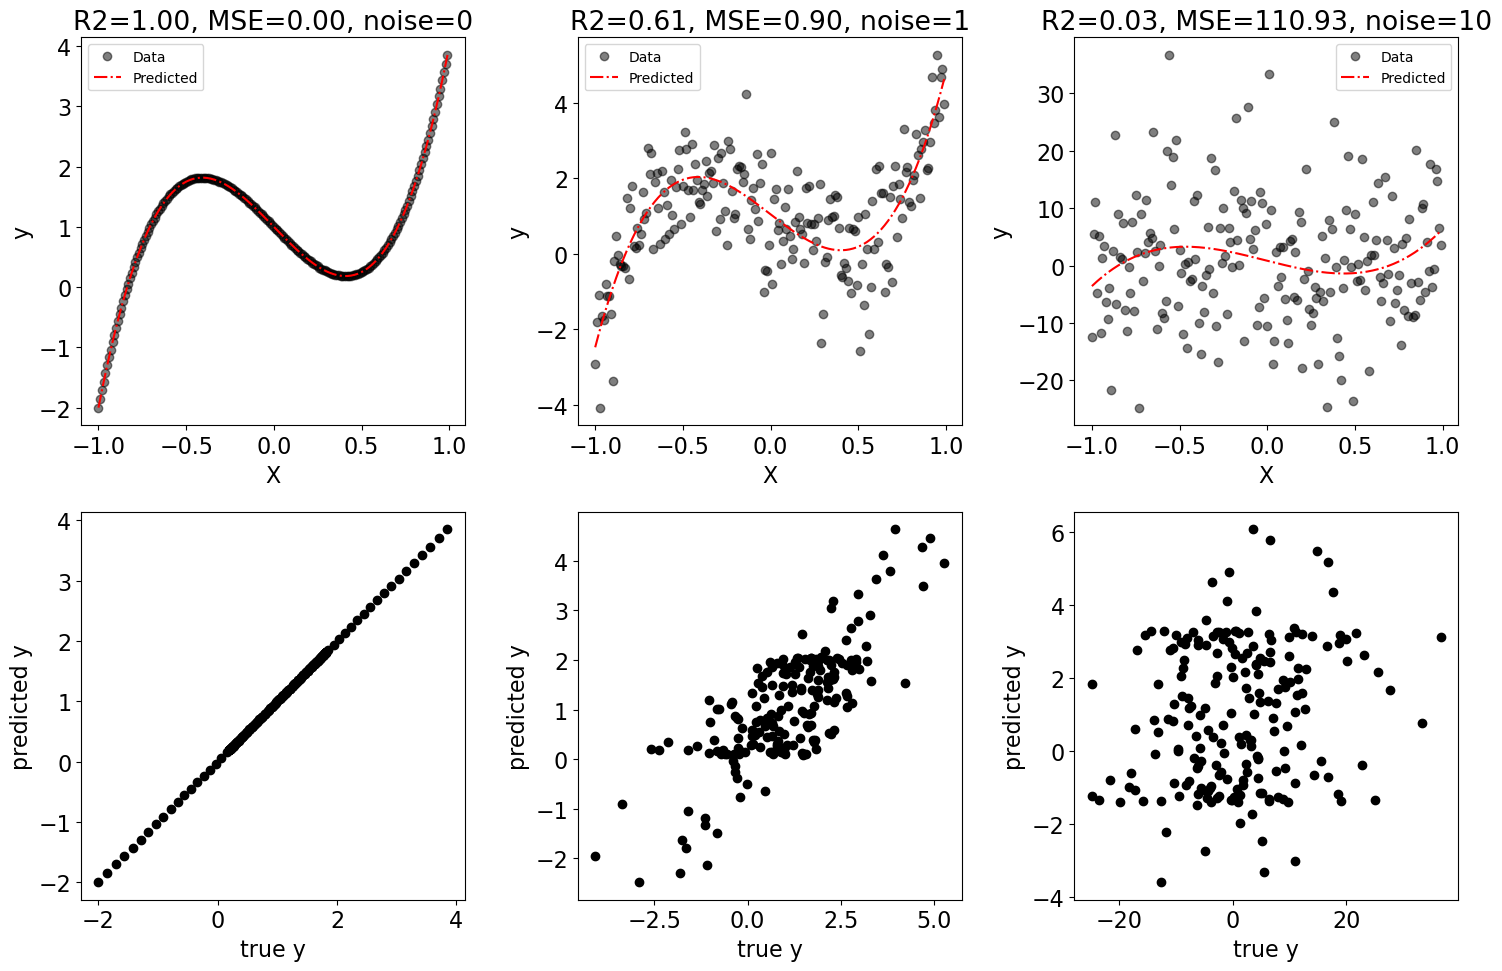

In [35]:
X=np.array(np.arange(-1,1,10**-2))
fig,ax=plt.subplots(2,3,figsize=(15,10))

for k,epsilon in enumerate([0,1,10]):
    y = 1-3*X+6*X**3 +epsilon*np.random.randn(len(X))

    
    X1 = np.column_stack((X, X**2,X**3))
    X1 = sm.add_constant(X1)##adding the intercept
    
    df_=pd.DataFrame(X1,columns=['c','x','x²','x³'])
    
    model = sm.OLS( y , df_[['c','x','x²','x³']])##defining an Ordinary Least Square variable
    results = model.fit()##fitting it
    y_predict=results.predict(X1)# predict back what your target variable would be in that model
    R2=r2_score(y,y_predict)#evaluate R2
    MSE=mean_squared_error(y,y_predict)#evaluate MSE


    ax[0,k].plot(X,y,'ko',label='Data',linewidth=10,alpha=0.5)
    ax[0,k].plot(X,y_predict,'r-.',label='Predicted')
    ax[0,k].legend(loc='best',fontsize=10)
    ax[0,k].set_title('R2={0:.2f}, MSE={1:.2f}, noise={2}'.format(R2,MSE,epsilon))
    ax[0,k].set_xlabel('X')
    ax[0,k].set_ylabel('y')
    
    ax[1,k].plot(y,y_predict,'ko')
    ax[1,k].set_xlabel('true y')
    ax[1,k].set_ylabel('predicted y')
    print('epsilon',epsilon)
    print('fit param c= {0:.3f} beta1= {1:.3f} beta2= {2:.3f} beta3= {3:.3f}'.format(results.params['c'],results.params['x'],results.params['x²'],results.params['x³']))
    print('true param c= {0:.3f} beta1= {1:.3f} beta2= {2:.3f} beta3= {3:.3f}'.format(1,-3,0,6))
    print()
plt.tight_layout()
plt.show()

On the real data, even though you probably have no reason to model it with something else than a degree 1 polynomial

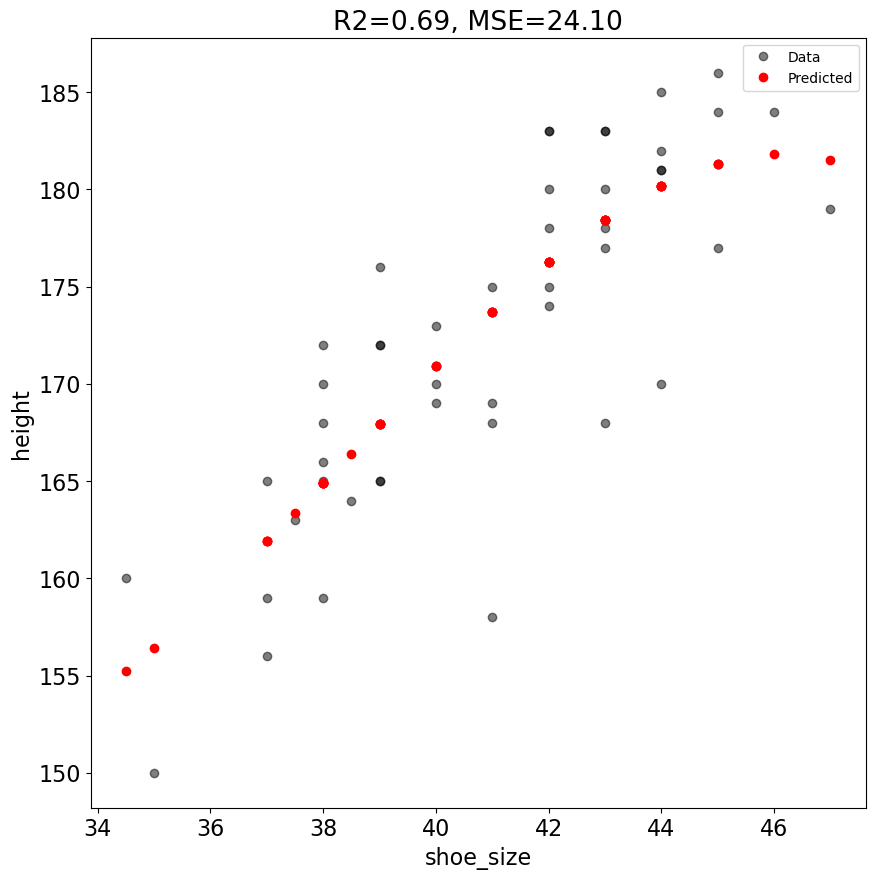

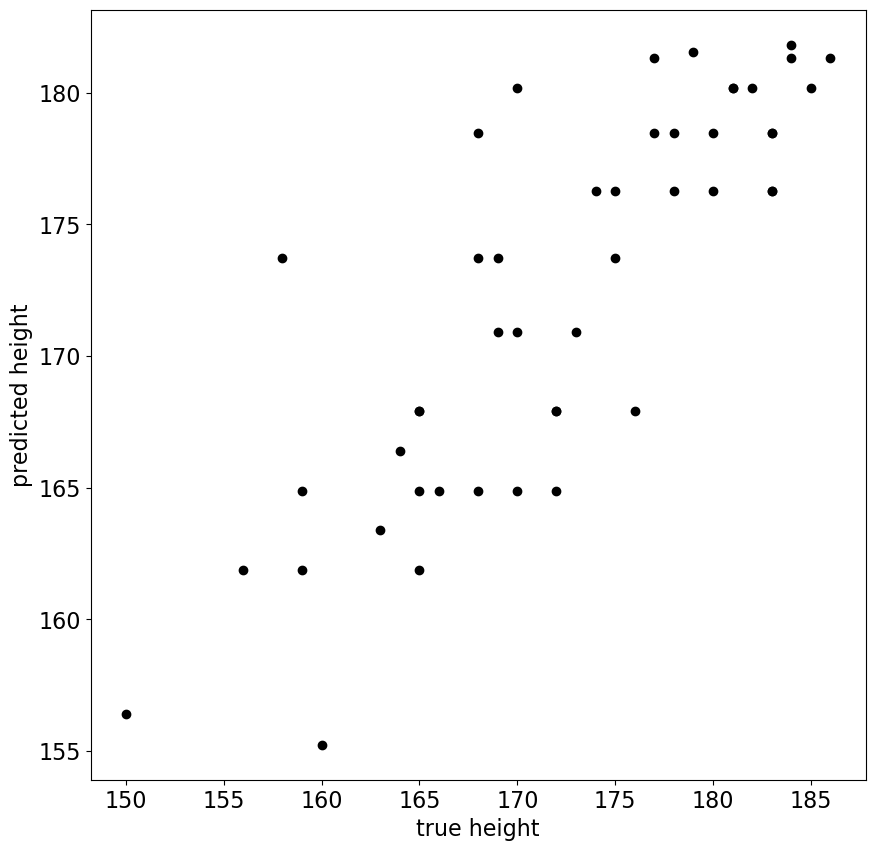

Intercept     1001.531461
shoe_size      -71.353360
shoe_size2       1.937473
shoe_size3      -0.016820
dtype: float64

In [36]:
df_extended=df.copy()
df_extended['shoe_size2']=df['shoe_size']**2
df_extended['shoe_size3']=df['shoe_size']**3
model = smf.ols(formula='height ~ shoe_size + shoe_size2 + shoe_size3', data=df_extended)

results = model.fit()#we do the actual fit
y_predict=results.predict(df_extended)# predict back what your target variable would be in that model
R2=r2_score(df_extended['height'],y_predict)
MSE=mean_squared_error(df_extended['height'],y_predict)

plt.plot(df_extended['shoe_size'] , df_extended['height'] ,'ko',label='Data',linewidth=10,alpha=0.5)
plt.plot(df_extended['shoe_size'] , y_predict ,'ro',label='Predicted')
plt.legend(loc='best',fontsize=10)
plt.title('R2={0:.2f}, MSE={1:.2f}'.format(R2,MSE))
plt.xlabel('shoe_size')
plt.ylabel('height')
plt.show()    

plt.plot( df_extended['height'], y_predict,'ko')
plt.xlabel('true height')
plt.ylabel('predicted height')
plt.show()

results.params

### E1.2 Multidimensional : more than 1 co-variable <a id='E1.2'></a>

Let see what that look like with our dataset

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     52.97
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.93e-12
Time:                        17:08:56   Log-Likelihood:                -139.86
No. Observations:                  47   AIC:                             285.7
Df Residuals:                      44   BIC:                             291.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     31.5602     19.324      1.633      0.1

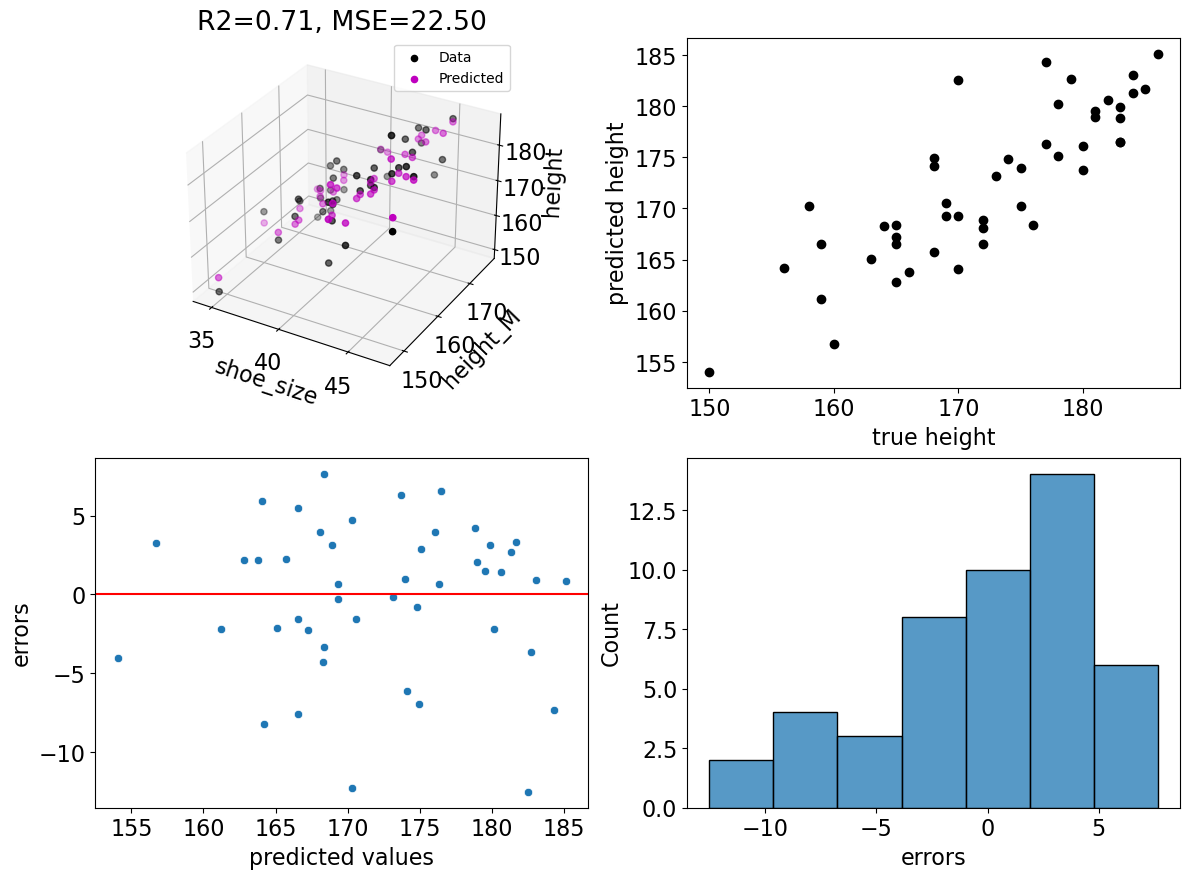

In [37]:
model = smf.ols(formula='height ~ shoe_size+height_M', data=df)

results = model.fit()#we do the actual fit
y_predict=results.predict(df)# predict back what your target variable would be in that model
R2=r2_score(df['height'],y_predict)
MSE=mean_squared_error(df['height'],y_predict)

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(221, projection='3d')
ax.scatter(df['shoe_size'], df['height_M'], df['height'], s=20, c='k',label='Data', depthshade=True)

ax.scatter(df['shoe_size'], df['height_M'],y_predict,label='Predicted' ,color='m')
ax.legend(loc='best',fontsize=10)
ax.set_title('R2={0:.2f}, MSE={1:.2f}'.format(R2,MSE))
ax.set_xlabel('shoe_size')
ax.set_ylabel('height_M')
ax.set_zlabel('height')

ax = fig.add_subplot(222)
ax.plot(df['height'],y_predict,'ko')
ax.set_xlabel('true height')
ax.set_ylabel('predicted height')

ax = fig.add_subplot(223)
sns.scatterplot(x=y_predict,y=results.resid , ax=ax) # plot the errors along x
ax.axhline(0,color='red')
ax.set_ylabel('errors')
ax.set_xlabel('predicted values')
ax = fig.add_subplot(224)
sns.histplot(results.resid , ax=ax) # plot an histogram of the errors
ax.set_xlabel('errors')


print(results.summary())

---

## 🏁 Closing Remarks

Congratulations on reaching the end of this notebook! Here is a brief recap of everything covered:

### Part 1 — Correlation
| Method | Best for | Range |
|--------|----------|-------|
| Pearson | Linear relationships | −1 to 1 |
| Spearman | Monotonic (non-linear) relationships | −1 to 1 |
| Kendall τ | Ordinal data, small samples, robust to outliers | −1 to 1 |

Remember: **correlation does not imply causation**, and a single coefficient can hide a complex or even non-existent relationship (recall the datasaurus dozen!).

### Part 2 — Linear Regression
- OLS finds $\hat{\boldsymbol{\beta}}$ by minimising the sum of squared residuals, with the closed-form solution $\hat{\boldsymbol{\beta}} = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{Y}$.
- Model quality is measured by $R^2_a$ (adjusted for the number of parameters) and MSE.
- Statistical inference on the coefficients (p-values, confidence intervals) requires the residuals to be (approximately) normally distributed.
- Always check the OLS assumptions: **homoskedasticity**, **no autocorrelation**, **no multicollinearity**, and **normality of residuals**.

### What comes next?
This notebook focused on **Ordinary Least Squares** for continuous response variables. If you keep exploring statistics and machine learning, you will soon encounter:
- **Generalised Linear Models (GLMs)** — for count data (Poisson regression) or binary outcomes (logistic regression).
- **Regularisation** (Ridge, Lasso) — to handle multicollinearity and prevent overfitting.
- **Cross-validation** — to get an honest estimate of out-of-sample predictive performance.
- **Causal inference** — when you want to go beyond association and make causal claims.

> *Statistics is the art of learning from data under uncertainty. The tools in this notebook are a solid foundation — use them carefully, check your assumptions, and always visualise your data!*

---
[⬆ Back to Table of Contents](#toc)